In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [4]:
# load data
data_path = r"C:\Users\user\OneDrive\Documents\Coding-frutiger\ml_portfolio\SIPRI-Milex-data-1949-2025(Current US$ (edited)).csv"

# create data variable
df_raw = pd.read_csv(data_path, encoding='latin-1')

# investigate structure
print(df_raw.shape)
df_raw.head(3)


(192, 77)


,Country,1949,1950,1951,1952,1953,1954,1955,1956,1957,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10407.3,10217.1,10073.4,9583.7,10303.6,9708.3,9112.5,9145.8,18264.0,21811.2


In [5]:
# Cleaning the data:

# setting Country as index:
df = df_raw.copy()
df = df.set_index('Country')

# Converting Year columns to non string (numeric):
df = df.apply(pd.to_numeric   , errors='coerce')

print(df.shape) # view transformaiton
print(f'Total NaN values: {df.isna().sum().sum()}') #first sum, sums all values per column, second sum, sums all of those to one value.

(192, 76)
Total NaN values: 5746


In [6]:
# 5746 NaN values reflects the sparcisity of the SIPRI coverage from earlier years and third world countries where data reporting is limited. 
# chunk down to a more narrow window, e.g. 1990-2023 for better coverage:
focus_years = [col for col in df.columns if 1990 <= int(col) <= 2023]
df = df[focus_years]

print(f'Columns in window: {len(focus_years)} ({focus_years[0]}–{focus_years[-1]})')
print(f'NaN values in window: {df.isna().sum().sum()}')

Columns in window: 34 (1990–2023)
NaN values in window: 1386


In [7]:
# Remove the Regions 
for name in df.index:
    print(name)

# remove the regions
regions = [
    'Africa', 'North Africa', 'Sub-Saharan Africa',
    'Americas', 'Central America and the Caribbean', 'North America',
    'South America', 'Asia & Oceania', 'Oceania', 'South Asia',
    'East Asia', 'South East Asia', 'Central Asia',
    'Europe', 'Central Europe', 'Eastern Europe', 'Western Europe',
    'Middle East', 'European Union'
]

df = df[~df.index.isin(regions)]

print(df.shape)

Africa
North Africa
Algeria
Libya
Morocco
Tunisia
sub-Saharan Africa
Angola
Benin
Botswana
Burkina Faso
Burundi
Cameroon
Cape Verde
Central African Republic
Chad
Congo, DR
Congo, Republic
Cote d'Ivoire
Djibouti
Equatorial Guinea
Eritrea
Ethiopia
Gabon
Gambia, The
Ghana
Guinea
Guinea-Bissau
Kenya
Lesotho
Liberia
Madagascar
Malawi
Mali
Mauritania
Mauritius
Mozambique
Namibia
Niger
Nigeria
Rwanda
Senegal
Seychelles
Sierra Leone
Somalia
South Africa
South Sudan
Sudan
Eswatini
Tanzania
Togo
Uganda
Zambia
Zimbabwe
Americas
Central America and the Caribbean
Belize
Costa Rica
Cuba
Dominican Republic
El Salvador
Guatemala
Haiti
Honduras
Jamaica
Mexico
Nicaragua
Panama
Trinidad and Tobago
North America
Canada
United States of America
South America
Argentina
Bolivia
Brazil
Chile
Colombia
Ecuador
Guyana
Paraguay
Peru
Uruguay
Venezuela
Asia & Oceania
Oceania
Australia
Fiji
New Zealand
Papua New Guinea
South Asia
Afghanistan
Bangladesh
India
Nepal
Pakistan
Sri Lanka
East Asia
China
Japan
Korea, Nort

In [8]:
# handling missing vlaues:
# drop countries misisng more than 50% of the 34 years 
threshold = len(df.columns) * 0.5 
df = df.dropna(thresh=int(threshold))

print(f"Countries after row NaN filter: {df.shape[0]}")
print(f'Remaining NaN: {df.isna().sum().sum()}')

Countries after row NaN filter: 161
Remaining NaN: 421


In [9]:
# adjustting for mean-fill to eliminate the rest of NaNs
df = df.fillna(df.mean())
print(f'Remaining NaN after fill: {df.isna().sum().sum()}')

Remaining NaN after fill: 0


In [10]:
# Normalizing the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f'Shape: {X_scaled.shape}')
print(f'Mean: {X_scaled.mean():.4f}')
print(f'Std: {X_scaled.std():.4f}')

Shape: (161, 34)
Mean: 0.0000
Std: 1.0000


In [11]:
# initialize 
k_range = range(2, 9) # K values to test: 2-8 clusters.

# store the scores for each K - use for plotting after loop
silhouette_scores = []
ch_scores = []

# Loop through each K, fit model, record quality metrics 
for k in k_range:

    # Fit K-means with K clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # fit_predict: fits the model and returns the cluster for each country
    labels = km.fit_predict(X_scaled)

    #Silhouette: how well each country fits its cluster vs. the nearest other cluster 
    # Range: -1 (wrong cluster) to +1 (well matched). Higher is better. 
    sil = silhouette_score(X_scaled, labels)
    
    # CH Index: Ratio of between-cluster spread to within-cluster spread
    # No fixed range - compare relative values across K. Higher is better
    ch = calinski_harabasz_score(X_scaled, labels)

    silhouette_scores.append(sil)
    ch_scores.append(ch)

    print(f'K={k} | silhouette: {sil:.4f} | CH Index: {ch:.1f}')

K=2 | silhouette: 0.9753 | CH Index: 1670.6
K=3 | silhouette: 0.8436 | CH Index: 2294.3
K=4 | silhouette: 0.8339 | CH Index: 3113.7
K=5 | silhouette: 0.7537 | CH Index: 3621.1
K=6 | silhouette: 0.6869 | CH Index: 4314.0
K=7 | silhouette: 0.4053 | CH Index: 4445.4
K=8 | silhouette: 0.3955 | CH Index: 4464.3


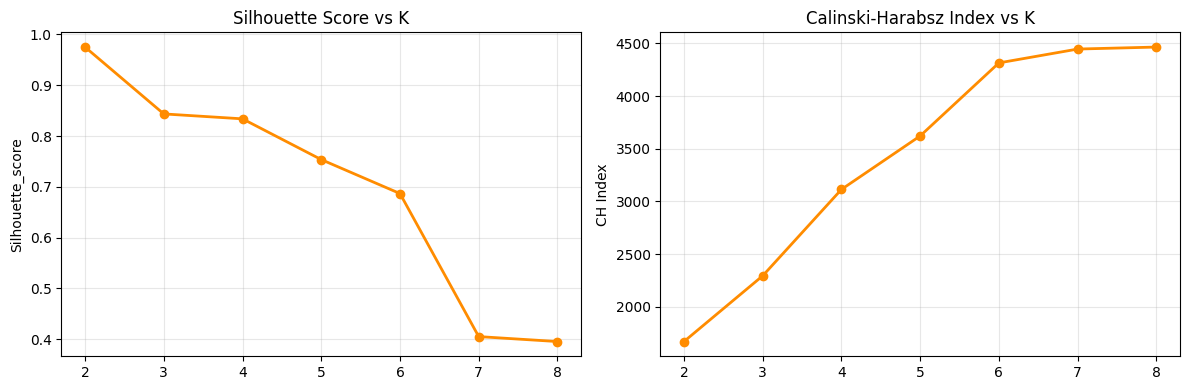

In [12]:
# Plotting:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Silhouette Score plot
ax1.plot(list(k_range), silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax1.set_title('Silhouette Score vs K')
ax1.set_label('Number of Clusterss (K)')
ax1.set_ylabel('Silhouette_score')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# CH index Plot 
ax2.plot(list(k_range), ch_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_title('Calinski-Harabsz Index vs K')
ax2.set_label('Number of Clusterss (K)')
ax2.set_ylabel('CH Index')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Both K = 5 and K = 6 seem reasonable. Running both in tandem to compare side by side. 

In [13]:
# Model fit  with K=5
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add clustered assignmnets back to the original dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print('Cluster Distribution (K=5):')
print(df_clustered['Cluster'].value_counts().sort_index())

Cluster Distribution (K=5):
Cluster
0    144
1      1
2     11
3      4
4      1
Name: count, dtype: int64


In [14]:
# Model fit  with K=5
OPTIMAL_K = 6

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add clustered assignmnets back to the original dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print('Cluster Distribution (K=6):')
print(df_clustered['Cluster'].value_counts().sort_index())

Cluster Distribution (K=6):
Cluster
0    140
1      1
2     12
3      4
4      3
5      1
Name: count, dtype: int64


In [15]:
# Tranformaing log to log values
import numpy as np

#log-transform the data before scaling 
#adding 1 to avoide log(0) errors on any zero values
df_log = np.log1p(df)

#re-scale the log-transformation data 
scaler_log = StandardScaler()
X_log_scaled = scaler_log.fit_transform(df_log)

print(f'Shape: {X_log_scaled.shape}')
print(f'Mean: {X_log_scaled.mean():.4f}')
print(f'Std: {X_log_scaled.std():.4f}')

Shape: (161, 34)
Mean: -0.0000
Std: 1.0000


In [ ]:
# empty lists to store new scores
silhouette_score_log = []
ch_scores_log = []

# run the model loop: generate new set of k
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_log_scaled)

    sil = silhouette_score(X_log_scaled, labels)
    ch = calinski_harabasz_score(X_log_scaled, labels)

    silhouette_score_log.append(sil)
    ch_scores_log.append(ch)

    print(f'K={k} | Silhouette: {sil:.4f} | CH Index: {ch:.1f}')

K=2 | Silhouette: 0.4278 | CH Index: 163.7
K=3 | Silhouette: 0.3583 | CH Index: 142.0
K=4 | Silhouette: 0.3190 | CH Index: 121.3
K=5 | Silhouette: 0.3122 | CH Index: 107.5
K=6 | Silhouette: 0.3284 | CH Index: 101.4
K=7 | Silhouette: 0.2607 | CH Index: 90.4
K=8 | Silhouette: 0.2857 | CH Index: 85.3


## Analysis:
Comparing these values to the original scores, it can be seen that both the Silhouette and CH Index have been significantly reduced almost across the board. The Silhouette scores appear approximately halved from K=2 through K=6, after which that trend weakens at K=7 and K=8.

The CH Index at K=2 is roughly a tenth of its original value, with subsequent values dropping even further. In the original run the CH Index increased with higher K values, however with log transformation the values are now decreasing - changing our transformation has reversed the trade-off decision profile. I.e. as we separate into further groups, our internal cohesion is dropping but so too is the separation between those groups i.e. as the grouping grow it becomes more and more challenging for the algorithm to tell the difference between clusters while at the same time the clusters become less and less internally cohesive.

### Why Did the Scores Drop?
Log transformation compressed the extreme values, creating a flatter feature landscape and decreasing the algorithm's ability to identify differences between countries. Clusters naturally overlap more as a result, hurting both metrics.

### CH Index Reversal:
In the original data, higher K values continued to improve separation because the outliers drew the extremes so far apart that the algorithm could identify clear boundaries — artificially. Removing this distortion via log transformation means the data no longer retains strong cluster structure, therefore both metrics decline in tandem.

### K=2 Conclusion:
According to the metrics this is technically the optimal balance, however it provides no additional context.

### Overall Conclusion on Normalization Technique:
Log transformation as a normalization technique is not helpful in this context. The discrepancy between large and small spenders is so vast that taking the log provides no meaningful clustering structure. The original data has a clustering structure but it is almost entirely driven by outliers.

This finding reveals a certain truth about military spending: global military expenditure is dominated by a handful of players and meaningful segmentation of the full dataset is challenging. A separate analysis would likely be needed for two structurally distinct spending categories.


In [18]:
# Removing Outliers - top spenders 

#average spending accross all years for each country: 
df_avg  = df.mean(axis = 1).sort_values(ascending=False)

print(df_avg.head(10))

Country
United States of America    537918.235294
China                       104388.332353
United Kingdom               54441.782353
Japan                        45240.279412
France                       44531.420588
Russia                       41924.935555
Germany                      40356.161765
Saudi Arabia                 40219.455882
India                        35046.020588
Italy                        26578.176471
dtype: float64


In [19]:
# see top 20:
print(df_avg.head(20))

Country
United States of America    537918.235294
China                       104388.332353
United Kingdom               54441.782353
Japan                        45240.279412
France                       44531.420588
Russia                       41924.935555
Germany                      40356.161765
Saudi Arabia                 40219.455882
India                        35046.020588
Italy                        26578.176471
Korea, South                 25960.176471
Brazil                       18812.297059
Australia                    17131.220588
Canada                       15497.929412
Spain                        15249.655882
Israel                       13098.085294
Türkiye                      12823.220588
Taiwan                       10120.776471
United Arab Emirates         10020.173407
Netherlands                   9638.867647
dtype: float64


## Outliers:
The US and China are the clear structural outliers. China spends approximately double the next nearest spender, the UK, while the US spends nearly five times China. One might make an argument for the Netherlands as well, however at only $400 million below the UAE it is likely not significant enough to warrant removal.

In [20]:
# Removing the US & China
outliers = ['United States of America', 'China']
df_subset = df[~df.index.isin(outliers)]

print(f'Countries Remaining: {df_subset.shape[0]}')

Countries Remaining: 159


In [21]:
# Re-scale without the outliers
scaler_subset = StandardScaler()
X_subset_scaled = scaler_subset.fit_transform(df_subset)

silhouette_scores_subset = []
ch_scores_subset = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_subset_scaled)
    
    sil = silhouette_score(X_subset_scaled, labels)
    ch = calinski_harabasz_score(X_subset_scaled, labels)
    
    silhouette_scores_subset.append(sil)
    ch_scores_subset.append(ch)
    
    print(f'K={k} | Silhouette: {sil:.4f} | CH Index: {ch:.1f}')

K=2 | Silhouette: 0.8472 | CH Index: 385.3
K=3 | Silhouette: 0.7839 | CH Index: 317.5
K=4 | Silhouette: 0.6998 | CH Index: 344.9
K=5 | Silhouette: 0.4332 | CH Index: 331.3
K=6 | Silhouette: 0.4043 | CH Index: 313.2
K=7 | Silhouette: 0.3981 | CH Index: 289.6
K=8 | Silhouette: 0.3790 | CH Index: 264.9


## Analysis on Normalizing w/ Removing Outliers:
The scores dropped significantly following normalization and outlier removal. Whether this matters depends on how much weight is placed on absolute metric values vs. relative patterns across K values.

Cluster K=4 found an interesting pocket by which to identify separation in countries, however K=2 still retained both the strongest separation and cohesion metrics.

This suggests the algorithm may still be struggling to identify clear patterns. Given that normalization appears to be suppressing meaningful structure, removing it may be worth exploring.

In [22]:
# Subset only, NO scaling
silhouette_scores_raw = []
ch_scores_raw = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_subset.values)
    
    sil = silhouette_score(df_subset.values, labels)
    ch = calinski_harabasz_score(df_subset.values, labels)
    
    silhouette_scores_raw.append(sil)
    ch_scores_raw.append(ch)
    
    print(f'K={k} | Silhouette: {sil:.4f} | CH Index: {ch:.1f}')

K=2 | Silhouette: 0.8543 | CH Index: 446.7
K=3 | Silhouette: 0.7280 | CH Index: 377.3
K=4 | Silhouette: 0.7319 | CH Index: 351.8
K=5 | Silhouette: 0.5214 | CH Index: 387.2
K=6 | Silhouette: 0.5159 | CH Index: 356.7
K=7 | Silhouette: 0.5122 | CH Index: 329.5
K=8 | Silhouette: 0.5115 | CH Index: 311.3


## Analysis Non-normalized w/ Subset:
The CH Index is still descending in values with a spike mid-way, but this time at K=5 instead of K=4. This mirrors the original distinction earlier in the K=5 vs K=6 comparison prior to any transformation.

The strongest combination still remains K=2, as it did with normalization and subsetting. However, it must be noted that the drop off between K=4 and K=5 without normalization is more dramatic — from 0.73 to 0.52 — compared to the normalized result of 0.69 to 0.43. The final Silhouette scores are grouped closer together, staying within the 0.5 range.

### Silhouette Improvement:
Removing normalization improved Silhouette scores, which are consistently stronger across every K compared to the normalized set.

### K=4 / K=5 CH Spike:
This suggests there is something structurally real around this range. The algorithm continues to find a pocket of improved separation regardless of normalization.

### Recommendation and Conclusion:
Choosing K=4 provides the last strong Silhouette score prior to the observed drop off. The CH spike suggests a real separation pattern with enough clusters to provide analytical interest. K=2 is cleaner but provides no additional context.

In [23]:
# Final Model - subset (no US / China), no normalization, K=4 
OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(df_subset.values)

# Add cluster labels back to the dataframe: 
df_clustered = df_subset.copy()
df_clustered['Cluster'] = cluster_labels

print('Cluster distribution:')
print(df_clustered['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    143
1      9
2      4
3      3
Name: count, dtype: int64


## Analysis:
If we look at our original regression model we found defense spending to be quite linear. Perhaps the issue is that defense spending is relatively linear and regular, therefore it is challenging to find clusters that are meaningful among the trends over time.

This might explain the continual clustering of most countries into Cluster 0.

In [25]:
# identify who is within each cluster:
for c in range(OPTIMAL_K):
    countries = df_clustered[df_clustered['Cluster'] == c].index.tolist()
    print(f'\n--- Cluster {c} ({len(countries)}) ---')
    print(', '.join(sorted(countries)))



--- Cluster 0 (143) ---
Afghanistan, Albania, Algeria, Angola, Argentina, Armenia, Austria, Azerbaijan, Bahrain, Bangladesh, Belarus, Belgium, Belize, Benin, Bolivia, Bosnia and Herzegovina, Botswana, Brunei, Bulgaria, Burkina Faso, Burundi, Cambodia, Cameroon, Cape Verde, Central African Republic, Chad, Chile, Colombia, Congo, DR, Congo, Republic, Costa Rica, Cote d'Ivoire, Croatia, Cuba, Cyprus, Czechia, Denmark, Djibouti, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Eswatini, Ethiopia, Fiji, Finland, Gabon, Gambia, The, Georgia, Ghana, Greece, Guatemala, Guinea, Guinea-Bissau, Guyana, Haiti, Honduras, Hungary, Iceland, Indonesia, Iran, Iraq, Ireland, Jamaica, Jordan, Kazakhstan, Kenya, Korea, North, Kuwait, Kyrgyz Republic, Laos, Latvia, Lebanon, Lesotho, Liberia, Libya, Lithuania, Luxembourg, Madagascar, Malawi, Malaysia, Mali, Malta, Mauritania, Mauritius, Mexico, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Namibia, Nepal, Netherlands, New Zealand, N

## Analysis of Clusters:

### Cluster 3:
India, Russia, Saudi Arabia: Three countries with dramatic, non-linear spending trajectories. Russia's post-Soviet collapse and re-militarization, Saudi Arabia's oil-driven surges, India's sustained ramp-up.

### Cluster 2:
France, Germany, Japan, UK: Established Western powers with large but relatively stable, mature defense budgets. NATO's core European spenders plus Japan.

### Cluster 1:
Australia, Brazil, Canada, Israel, Italy, South Korea, Spain, Türkiye, UAE: Mid-tier spenders with regional significance. A mix of NATO members, emerging powers, and energy-rich states.

### Cluster 0:
Everyone else: The 143 countries with low, flat, linear trajectories.

Possibly alludes to structural breaks throughout history whereby these specific countries are aligned with significant moments where defense spending changed e.g. Soviet collapse, regional significance either in Asia, South America or Europe, and global crisis moments e.g. 2008.

### Conclusion:
The dissolution of the USSR affected more than just the Soviet Union, as did 2008. Most of the countries impacted by these global events are still sitting within Cluster 0 e.g. Armenia, Azerbaijan, Belarus, Georgia etc. These effects aren't being separated out likely due to budget magnitude. Their spending trajectories likely did structurally change, however the dollar values are so small compared to Russia that the distance in feature space is negligible. The algorithm remains hypersensitive to scale even without outliers. This is a limitation.

Further, any country with a missing value was filled with the annual mean, therefore their trajectory was essentially flattened artificially toward the average. These observations are not going to cluster anywhere other than 0 as there is no interaction effect to pull inference from — not because the spending itself was average, but because the methodology manufactured it to be. This highlights that the data integrity issue undermines confidence in the size of Cluster 0.

However, cluster separation cannot be purely attributed to budget size. Countries such as UAE, South Korea, France, Germany and the UK are significant regional players, likely owning distinct spending needs and patterns. They spend significantly less than Russia yet still show up in their own clusters, as do Saudi Arabia and India. Trajectory shape is clearly doing some work. Magnitude is simply muddying the waters.

In [26]:
# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_subset.values)

explained = pca.explained_variance_ratio_
print(f'PC1 explains: {explained[0]*100:.1f}% of variance')
print(f'PC2 explains: {explained[1]*100:.1f}% of variance')
print(f'Total explained: {sum(explained)*100:.1f}%')

PC1 explains: 89.7% of variance
PC2 explains: 5.9% of variance
Total explained: 95.6%


## Analysis of PCA:
PC1 accounts for 89.7% of the data which reinforces the previous interpretation that there seems to be one dimension which fully explains, or at least dominates, the data i.e. magnitude. PC2 is likely capturing trajectory shape differences.

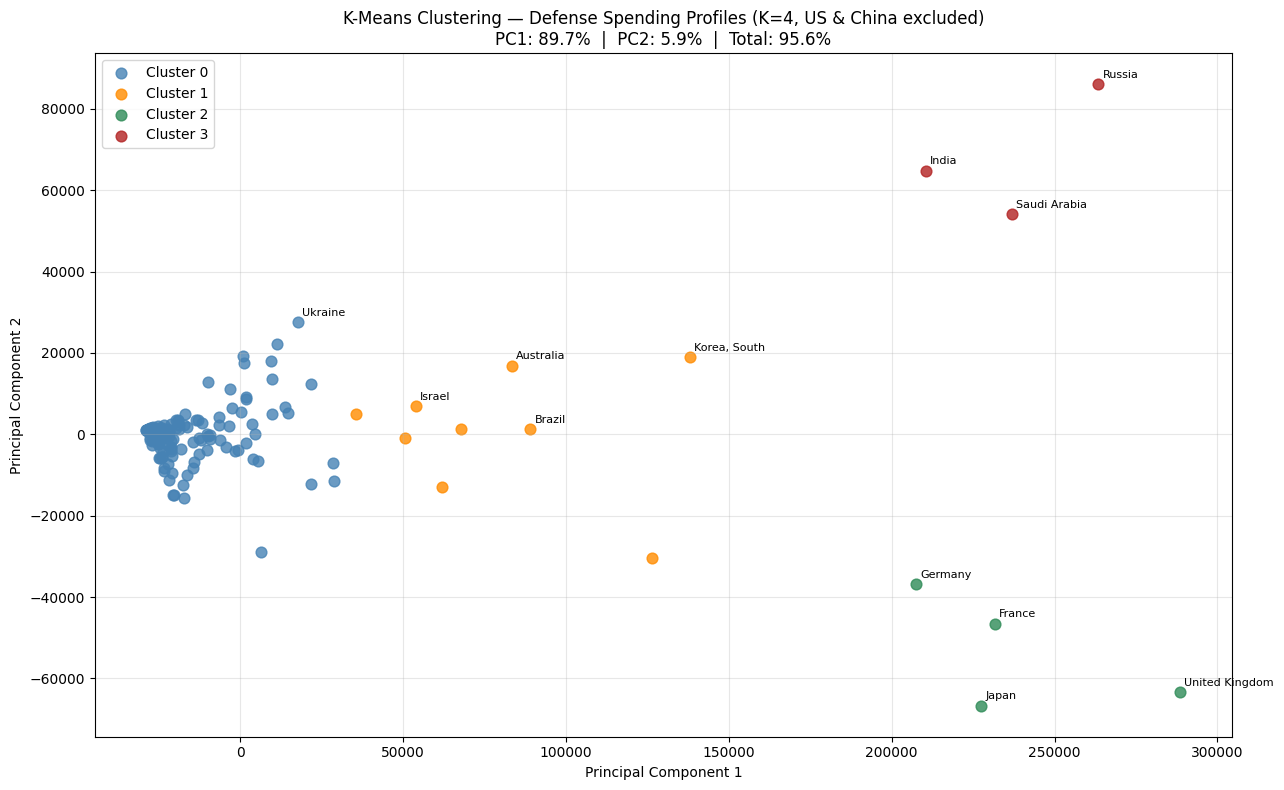

In [33]:
# Plotting the PCs

# build dataframe for plotting: 
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'Country': df_subset.index
})

# design
palette = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

# plot size
fig, ax = plt.subplots(figsize=(13,8))

# loop through the data:
for c in range(OPTIMAL_K):
    mask = df_pca['Cluster'] == c
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               color=palette[c], label=f'Cluster {c}', s=60, alpha=0.8)

# Label notable countries
notable = ['United Kingdom', 'Russia', 'Germany', 'France',
           'India', 'Saudi Arabia', 'Japan', 'Brazil',
           'Israel', 'Australia', 'Korea, South', 'Ukraine']

# annotate notable countries
for _, row in df_pca[df_pca['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'], (row['PC1'], row['PC2']),
                fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
    
ax.set_title(f'K-Means Clustering — Defense Spending Profiles (K={OPTIMAL_K}, US & China excluded)\n'
             f'PC1: {explained[0]*100:.1f}%  |  PC2: {explained[1]*100:.1f}%  |  Total: {sum(explained)*100:.1f}%',
             fontsize=12)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Chart Analysis:
PC1 is almost purely spending magnitude i.e. the further along the x-axis a country is, the higher their spending. Clusters 2 and 3 find themselves both far along this dimension but we see a Western and Eastern split along the y-axis i.e. PC2.

PC2 could be separating growth trajectory direction. That being, for Cluster 3, these countries ramped up spending significantly over the post-Cold War period. Cluster 2 on the other hand sits negatively on PC2. These countries had high spending early on but perhaps flattened over time since the 1990s — Cold War era spending tapering off.

The real story could be growing vs declining defense spending relative to a country's own history. It is not exactly East vs West, but it is indicative of how world events have affected trajectory over time. Geography and trajectory are perhaps correlated.

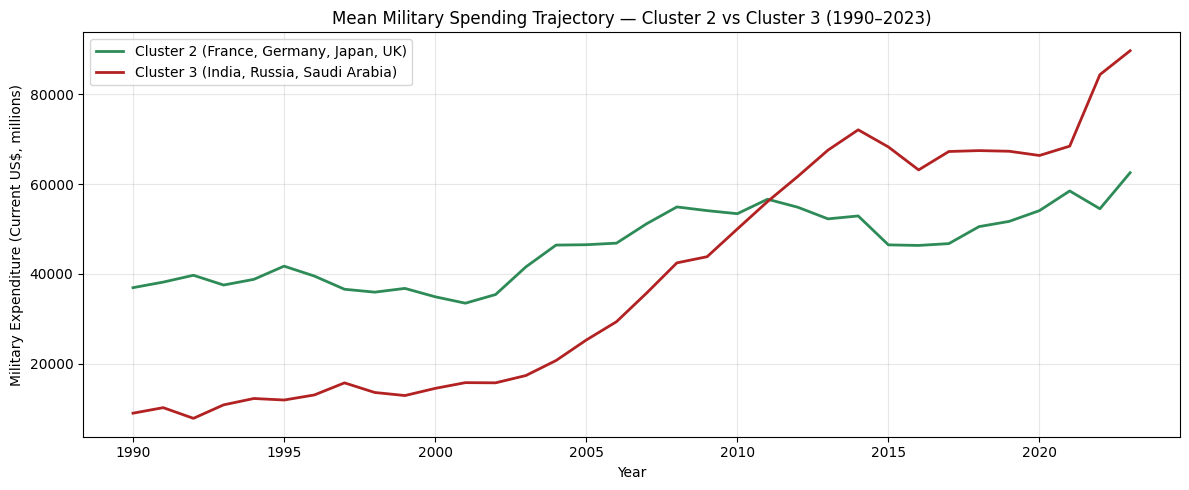

In [34]:
# Mean spending trajectory for clusters 2 and 3 over time
cluster_2 = df_clustered[df_clustered['Cluster'] == 2].drop(columns='Cluster').mean()
cluster_3 = df_clustered[df_clustered['Cluster'] == 3].drop(columns='Cluster').mean()

plt.figure(figsize=(12, 5))
plt.plot(cluster_2.index.astype(int), cluster_2.values, 
         color='seagreen', linewidth=2, label='Cluster 2 (France, Germany, Japan, UK)')
plt.plot(cluster_3.index.astype(int), cluster_3.values, 
         color='firebrick', linewidth=2, label='Cluster 3 (India, Russia, Saudi Arabia)')

plt.title('Mean Military Spending Trajectory — Cluster 2 vs Cluster 3 (1990–2023)')
plt.xlabel('Year')
plt.ylabel('Military Expenditure (Current US$, millions)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Chart Analysis:
In the above line chart we see a reinforcement of that general trend. Cluster 3 defense spending increasing significantly post 2000 while Cluster 2 remains, relatively, stable.

Cluster 2 starts higher in 1990 as France, Germany and the UK were already established Cold War era spenders. Their spending is relatively flat, as stated, with a small uptick around the 2000s and peaking just after the 2008 financial crisis, followed by a general tapering off until around 2020. This is likely a result of the Ukraine war and NATO recommitment.

Cluster 3 starts much lower and crosses Cluster 2 at around 2010. This is the point where ramping objectives overtook Western spenders in average terms. Russia's petrodollar, Saudi Arabia's oil wealth and India's sustained growth all converging around the same time.

### 2022 Spike:
The Ukraine invasion and Gulf regional tensions appear to drive a sharp late period surge.

## Conclusion: 

### Cluster 0 — General Population
Cluster 0 seems to be a catch all. The grouping of most countries in this case, 143, whom have "regular" spending habits and trajectories. This group likely has a linear spending trajectory and is far too thin in the feature space between each data point for the algorithm to pull any discernible context. This seems to be typical of most countries and their defense spending habit. For these countries defense is likely an important expenditure but it does not define their economy, political objectives or capabilities. 

### Cluster 1 — Regional Mid-Tier Powers
This cluster may be indicative of countries whom are smaller compared to the behemoths of large regional players on either hemisphere, though, who still retain significant relevance to their particular region. Israel, for example, is the United States' chiefest ally in the Middle East region and receives defense spending aid yearly. South Korea is a growing player on the world stage and is a more "Western" society, much like Japan, that sits far to the east among deeply combative and ideologically different players, for example North Korea and China (China being the second largest spender on defense).

### Cluster 2 — Old Players
This cluster seems to be indicative of the classic defense spending nations that take prominent place in history. These countries were also prominent players in WW1 and WW2, however more recently have seen focus on other geo-political and domestic economic issues other than defence. It could be that they are not attempting to play the war games as they once did post WW2, shadowed out by the US, China and Russia. 

### Cluster 3 — The Odd Group
This cluster is representative of those countries whom have increased defense spending rapidly as a bid, likely, to use this factor to compete geo-politically. Tensions between the USA and Russia are evident via the Cold War where both countries spent heavily in defense. Russia continues to test its place on the world stage, evident by its invasion of Ukraine in 2022. Saudi Arabia has likely seen an increase in spending due to political tensions in the Gulf Area along with Israel, Palestine and Iran to name a few in recent history. India has the single largest population on the planet; defense spending has likely increased as a means to foster their own military industrial complex and compete on the world stage. Cluster 3 countries are likely using defence spending specifically with the intention to create economic advantages as the US did. 

---

### Model Assessment
The model is assessed to be of relative accuracy with some limitations for further review. Geo-politically the clusters do map well onto the general trends, actions and policies of countries across the time period shown. The limitations are obvious — magnitude remains a significant factor that dilutes the algorithm's ability to determine cluster separation i.e. CH Index. Normalisation further complicates the issue because magnitude is such a determining factor that squishing the difference in observations within the feature space simply exasperates the issue. Further, the methodology of taking the mean value of spending to fill in blank observations likely accounted for further squishing and likely explains the significant size of Cluster 0. With more data collected and the removal of outliers it could be possible to get better separation effect in clusters. 

Generally it seems evident that this project supports the claim that past defense spending is indicative of future defense spending trajectory. It is very rare to see the opposite occur. Magnitude of defense spending seems to be the single greatest factor, so far, that determines the structural difference between countries when attempting to group them via this trajectory. It does however seem possible that long-term economic and political focuses can make a secondary determinantal impact on this pattern in that countries that either reinforce or alter their focus from defense spending, clearly, overtime can determine which cluster they fall into, relative to how long they've held that policy for.

---

### What I Can Say About This Project
I used K-Means clustering to segment countries by their military spending trajectory over a 34-year post-Cold War window. I found that magnitude of spending was the single greatest factor for country clustering with respect to defense spending, and economic/political policy choices as a result of historical events act as a smaller but still relevant factor. The clustered groups are meaningful but more accurate data coupled with a deeper individual dive into the idiosyncrasies of each major country would likely assist in determining the clustering factors.